In [1]:
import pandas as pd

df = pd.read_csv("final_unified_dataset.csv")

print("Total Samples:", len(df))
print("\nClass Distribution:")
print(df['label'].value_counts())

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDuplicate Rows:", df.duplicated().sum())

Total Samples: 59719

Class Distribution:
label
Not_Fraud    30804
Fraud        28915
Name: count, dtype: int64

Missing Values:
text     0
label    0
dtype: int64

Duplicate Rows: 9


In [2]:
df.drop_duplicates(inplace=True)

In [3]:
print("\nDuplicate Rows:", df.duplicated().sum())


Duplicate Rows: 0


In [4]:
#adding Text FEatures
df['text_length'] = df['text'].apply(len)
df['word_count'] = df['text'].apply(lambda x: len(x.split()))
df['uppercase_count'] = df['text'].apply(lambda x: sum(1 for c in x if c.isupper()))
df['digit_count'] = df['text'].apply(lambda x: sum(1 for c in x if c.isdigit()))
df['url_count'] = df['text'].str.count('http')
df['exclamation_count'] = df['text'].str.count('!')

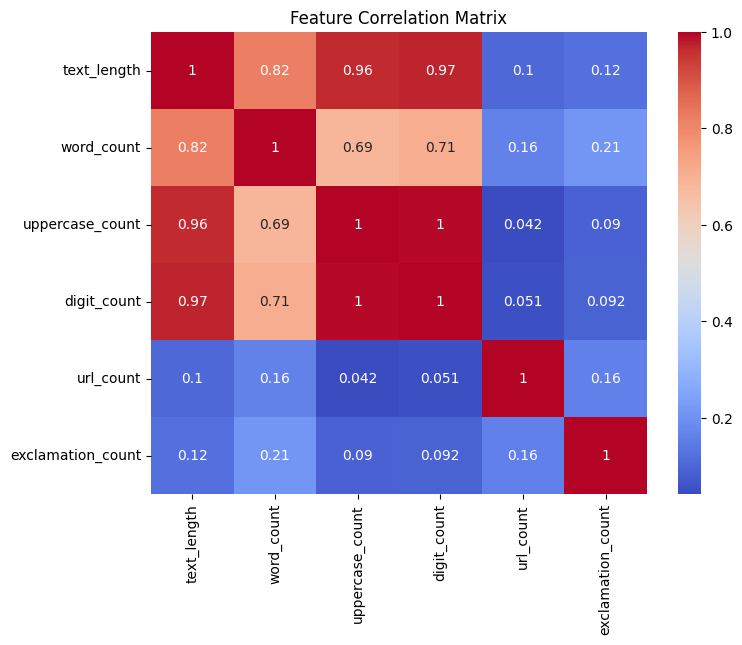

In [7]:
import seaborn as sns
import matplotlib.pyplot as plt

numeric_df = df[['text_length', 'word_count', 'uppercase_count',
                 'digit_count', 'url_count', 'exclamation_count']]

correlation = numeric_df.corr()

plt.figure(figsize=(8,6))
sns.heatmap(correlation, annot=True, cmap='coolwarm')
plt.title("Feature Correlation Matrix")
plt.show()

In [8]:
df['label_num'] = df['label'].map({'Not_Fraud':0, 'Fraud':1})

In [9]:
feature_corr = df.corr(numeric_only=True)

print(feature_corr['label_num'].sort_values(ascending=False))

label_num            1.000000
url_count            0.024039
exclamation_count    0.023417
uppercase_count      0.008367
digit_count         -0.001261
text_length         -0.020968
word_count          -0.111173
Name: label_num, dtype: float64


In [10]:
print(df.describe())

        text_length     word_count  uppercase_count    digit_count  \
count  5.971000e+04   59710.000000     5.971000e+04   59710.000000   
mean   1.880146e+03     258.569251     1.528413e+02      75.864646   
std    1.972275e+04     774.218321     6.674907e+03    3052.464817   
min    2.000000e+01       1.000000     0.000000e+00       0.000000   
25%    3.280000e+02      50.000000     6.000000e+00       2.000000   
50%    7.800000e+02     120.000000     2.300000e+01      17.000000   
75%    2.082000e+03     303.000000     7.600000e+01      42.000000   
max    4.599694e+06  127127.000000     1.618796e+06  740710.000000   

          url_count  exclamation_count     label_num  
count  59710.000000       59710.000000  59710.000000  
mean       2.721169           1.204974      0.484257  
std       15.392638           8.120476      0.499756  
min        0.000000           0.000000      0.000000  
25%        0.000000           0.000000      0.000000  
50%        1.000000           0.000000 

In [11]:
print(df.groupby('label')[['text_length','word_count',
                           'uppercase_count','digit_count',
                           'url_count']].mean())

           text_length  word_count  uppercase_count  digit_count  url_count
label                                                                      
Fraud      1453.374027  169.743732       210.476950    71.891925   3.103026
Not_Fraud  2280.864231  341.972073        98.724241    79.594837   2.362624


In [13]:
import numpy as np
import joblib

# Load model and vectorizer
model = joblib.load("final_model.pkl")
vectorizer = joblib.load("final_vectorizer.pkl")

# Extract feature names and coefficients
feature_names = vectorizer.get_feature_names_out()
coefficients = model.coef_[0]

# Top 20 Fraud indicators (positive weights)
top_positive = np.argsort(coefficients)[-20:]

# Top 20 Legitimate indicators (negative weights)
top_negative = np.argsort(coefficients)[:20]

print("Top Fraud Words:")
for i in reversed(top_positive):
    print(f"{feature_names[i]} : {coefficients[i]:.4f}")

print("\nTop Legitimate Words:")
for i in top_negative:
    print(f"{feature_names[i]} : {coefficients[i]:.4f}")

d:\miniProject\.venv\Lib\site-packages\sklearn\base.py:463: InconsistentVersionWarning: Trying to unpickle estimator LogisticRegression from version 1.6.1 when using version 1.8.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
d:\miniProject\.venv\Lib\site-packages\sklearn\base.py:463: InconsistentVersionWarning: Trying to unpickle estimator TfidfTransformer from version 1.6.1 when using version 1.8.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


Top Fraud Words:
http : 6.5667
com : 5.7885
love : 5.5616
replica : 5.2178
health : 4.4089
monkey org : 4.2317
watches : 4.1483
account : 4.0589
cnn : 3.9816
jose : 3.7691
monkey : 3.7257
men : 3.7219
click : 3.6638
cy : 3.6431
dear : 3.4364
life : 3.3818
watch : 3.3742
money : 3.2712
jose monkey : 3.2228
video : 2.9117

Top Legitimate Words:
wrote : -7.3267
enron : -5.8614
python : -4.8520
thanks : -4.5500
org : -4.5284
university : -4.3733
opensuse : -4.2681
perl : -3.8653
postfix : -3.6649
language : -3.6116
edu : -3.5172
10 : -3.3518
date : -3.2484
2007 : -3.2284
url http : -3.1441
net : -3.1031
group : -3.0649
pm : -2.9453
cnet : -2.9045
nz : -2.8708


d:\miniProject\.venv\Lib\site-packages\sklearn\base.py:463: InconsistentVersionWarning: Trying to unpickle estimator TfidfVectorizer from version 1.6.1 when using version 1.8.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


In [15]:
from sklearn.feature_extraction.text import TfidfVectorizer
TfidfVectorizer(
    stop_words='english',
    max_df=0.9,
    min_df=5,
    ngram_range=(1,2)
)

,"input input: {'filename', 'file', 'content'}, default='content'- If `'filename'`, the sequence passed as an argument to fit is expected to be a list of filenames that need reading to fetch the raw content to analyze.- If `'file'`, the sequence items must have a 'read' method (file-like object) that is called to fetch the bytes in memory.- If `'content'`, the input is expected to be a sequence of items that can be of type string or byte.",'content'
,"encoding encoding: str, default='utf-8'If bytes or files are given to analyze, this encoding is used todecode.",'utf-8'
,"decode_error decode_error: {'strict', 'ignore', 'replace'}, default='strict'Instruction on what to do if a byte sequence is given to analyze thatcontains characters not of the given `encoding`. By default, it is'strict', meaning that a UnicodeDecodeError will be raised. Othervalues are 'ignore' and 'replace'.",'strict'
,"strip_accents strip_accents: {'ascii', 'unicode'} or callable, default=NoneRemove accents and perform other character normalizationduring the preprocessing step.'ascii' is a fast method that only works on characters that havea direct ASCII mapping.'unicode' is a slightly slower method that works on any characters.None (default) means no character normalization is performed.Both 'ascii' and 'unicode' use NFKD normalization from:func:`unicodedata.normalize`.",None
,"lowercase lowercase: bool, default=TrueConvert all characters to lowercase before tokenizing.",True
,"preprocessor preprocessor: callable, default=NoneOverride the preprocessing (string transformation) stage whilepreserving the tokenizing and n-grams generation steps.Only applies if ``analyzer`` is not callable.",None
,"tokenizer tokenizer: callable, default=NoneOverride the string tokenization step while preserving thepreprocessing and n-grams generation steps.Only applies if ``analyzer == 'word'``.",None
,"analyzer analyzer: {'word', 'char', 'char_wb'} or callable, default='word'Whether the feature should be made of word or character n-grams.Option 'char_wb' creates character n-grams only from text insideword boundaries; n-grams at the edges of words are padded with space.If a callable is passed it is used to extract the sequence of featuresout of the raw, unprocessed input... versionchanged:: 0.21 Since v0.21, if ``input`` is ``'filename'`` or ``'file'``, the data is first read from the file and then passed to the given callable analyzer.",'word'
,"stop_words stop_words: {'english'}, list, default=NoneIf a string, it is passed to _check_stop_list and the appropriate stoplist is returned. 'english' is currently the only supported stringvalue.There are several known issues with 'english' and you shouldconsider an alternative (see :ref:`stop_words`).If a list, that list is assumed to contain stop words, all of whichwill be removed from the resulting tokens.Only applies if ``analyzer == 'word'``.If None, no stop words will be used. In this case, setting `max_df`to a higher value, such as in the range (0.7, 1.0), can automatically detectand filter stop words based on intra corpus document frequency of terms.",'english'
,"token_pattern token_pattern: str, default=r""(?u)\\b\\w\\w+\\b""Regular expression denoting what constitutes a ""token"", only usedif ``analyzer == 'word'``. The default regexp selects tokens of 2or more alphanumeric characters (punctuation is completely ignoredand always treated as a token separator).If there is a capturing group in token_pattern then thecaptured group content, not the entire match, becomes the token.At most one capturing group is permitted.",'(?u)\\b\\w\\w+\\b'
,"ngram_range ngram_range: tuple (min_n, max_n), default=(1, 1)The lower and upper boundary of the range of n-values for differentn-grams to be extracted. All values of n such that min_n <= n <= max_nwill be used. For example an ``ngram_range`` of ``(1, 1)`` means onlyunigrams, ``(1, 2)`` means unigrams and bigrams, and ``(2, 2)`` meansonly bigrams.Only applies if ``analyzer`` is not callable.